<a href="https://colab.research.google.com/github/Dhanush7-tech/Deep-Learning-LAB/blob/main/lab-1/DeepLearning_Lab1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
#Task-1:

file_path = 'data_banknote_authentication.txt'
columns = ['Variance', 'Skewness', 'Curtosis', 'Entropy', 'Class']
df = pd.read_csv(file_path, names=columns)

print("--- First 5 Samples ---")
print(df.head())

print(f"\n--- Dataset Dimensions ---")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")

print("\n--- Missing Values ---")
print(df.isnull().sum())

print("\n--- Descriptive Statistics ---")
print(df.describe())

--- First 5 Samples ---
   Variance  Skewness  Curtosis  Entropy  Class
0   3.62160    8.6661   -2.8073 -0.44699      0
1   4.54590    8.1674   -2.4586 -1.46210      0
2   3.86600   -2.6383    1.9242  0.10645      0
3   3.45660    9.5228   -4.0112 -3.59440      0
4   0.32924   -4.4552    4.5718 -0.98880      0

--- Dataset Dimensions ---
Rows: 1372, Columns: 5

--- Missing Values ---
Variance    0
Skewness    0
Curtosis    0
Entropy     0
Class       0
dtype: int64

--- Descriptive Statistics ---
          Variance     Skewness     Curtosis      Entropy        Class
count  1372.000000  1372.000000  1372.000000  1372.000000  1372.000000
mean      0.433735     1.922353     1.397627    -1.191657     0.444606
std       2.842763     5.869047     4.310030     2.101013     0.497103
min      -7.042100   -13.773100    -5.286100    -8.548200     0.000000
25%      -1.773000    -1.708200    -1.574975    -2.413450     0.000000
50%       0.496180     2.319650     0.616630    -0.586650     0.000000
7

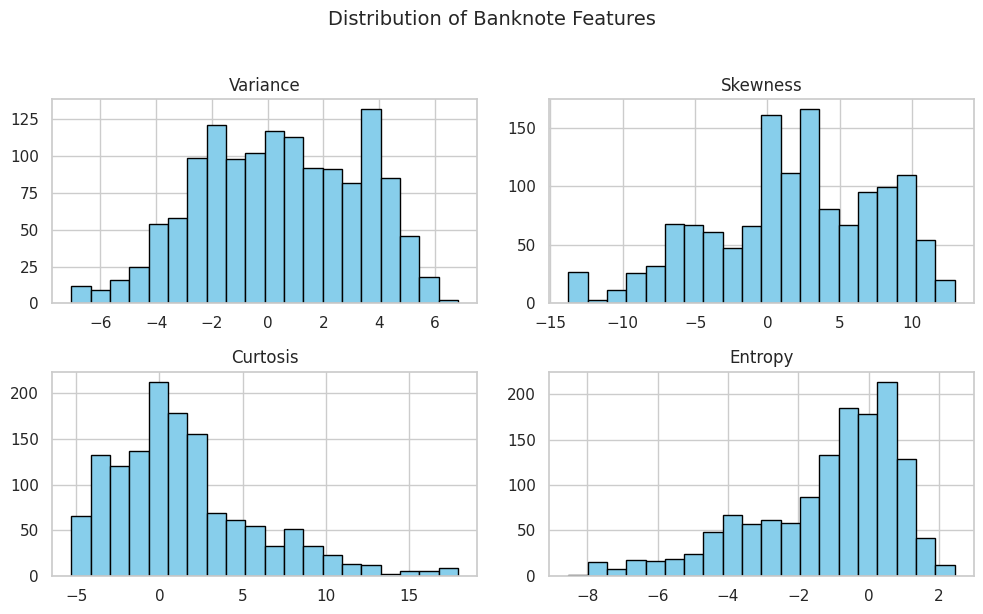

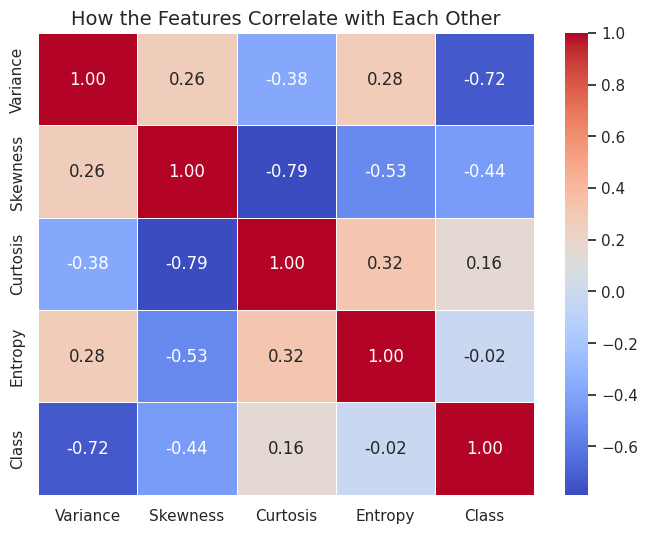

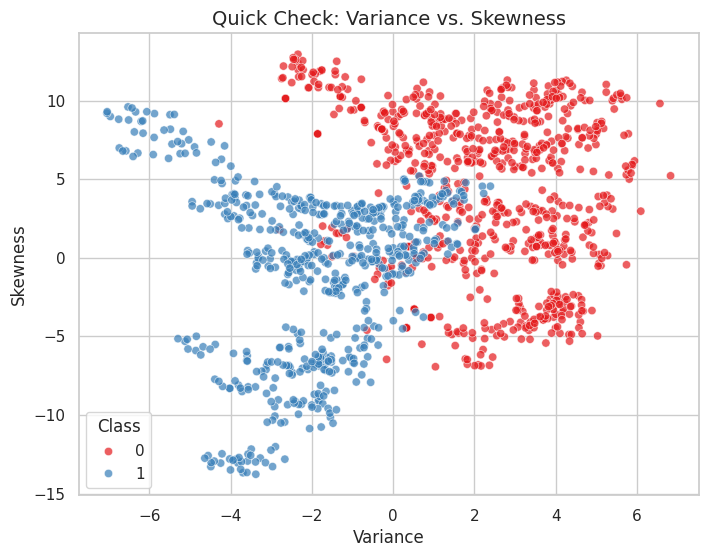

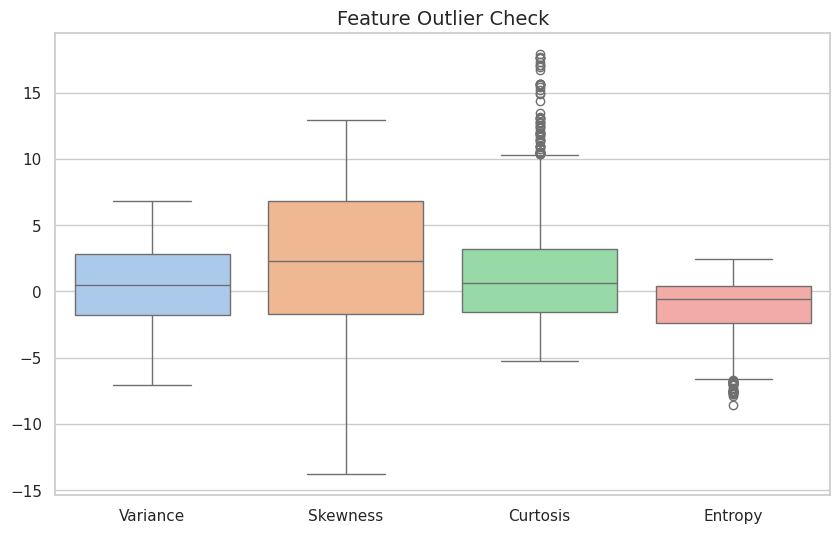

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# for clean background
sns.set_theme(style="whitegrid")

# 1.Histograms:
df.drop('Class', axis=1).hist(figsize=(10, 6), bins=20, edgecolor='black', color='skyblue')
plt.suptitle('Distribution of Banknote Features', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# 2.Correlation Heatmap:
plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(),annot=True,cmap='coolwarm',fmt=".2f", linewidths=0.5)
plt.title('How the Features Correlate with Each Other', fontsize=14)
plt.show()

# 3.Scatter Plot:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='Variance', y='Skewness', hue='Class', palette='Set1', alpha=0.7)
plt.title('Quick Check: Variance vs. Skewness', fontsize=14)
plt.show()

# 4. Boxplots:
plt.figure(figsize=(10, 6))
data=df.drop('Class', axis=1)
sns.boxplot(data,palette='pastel')
plt.title('Feature Outlier Check',fontsize=14)
plt.show()

In [ ]:
#Task-3
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1.Separate our features (X) from our target labels (y)
# X gets everything except the 'Class' column. y gets ONLY the 'Class' column.
X = df.drop('Class', axis=1).values
y = df['Class'].values

# 2.Split the dataset into Training (80%) and Testing (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3.Normalize
scaler = StandardScaler()

#Getting the scaled data
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Total dataset size: {X.shape[0]} rows")
print(f"Training set size (80%): {X_train_scaled.shape[0]} rows")
print(f"Testing set size (20%): {X_test_scaled.shape[0]} rows")

Total dataset size: 1372 rows
Training set size (80%): 1097 rows
Testing set size (20%): 275 rows


In [ ]:
#Task - 4 & 5:
import numpy as np

class SingleLayerPerceptron:
    def __init__(self, learning_rate=0.01, max_training_epochs=50):
        self.learning_rate = learning_rate
        self.max_training_epochs = max_training_epochs
        self.feature_weights = None
        self.bias_weight = None

    def step_activation(self, weighted_sum):
        return np.where(weighted_sum >= 0, 1, 0)

    def forward_propagation(self, sample_features):
        weighted_sum = np.dot(sample_features, self.feature_weights) + self.bias_weight
        return self.step_activation(weighted_sum)

    def fit(self, training_data_features, training_data_labels):
        total_samples, total_features = training_data_features.shape

        self.feature_weights = np.zeros(total_features)
        self.bias_weight = 0.0

        #  THIS IS THE CRUCIAL UPDATE
        self.misclassified_count_per_epoch = []
        self.weight_history = []
        self.bias_history = []

        print(f"--- Starting Training ---")

        for current_epoch in range(self.max_training_epochs):
            total_errors_this_epoch = 0

            for sample_index, current_sample_features in enumerate(training_data_features):
                predicted_class_label = self.forward_propagation(current_sample_features)
                actual_class_label = training_data_labels[sample_index]

                prediction_error = actual_class_label - predicted_class_label
                weight_adjustment_step = self.learning_rate * prediction_error

                self.feature_weights += weight_adjustment_step * current_sample_features
                self.bias_weight += weight_adjustment_step

                if weight_adjustment_step != 0.0:
                    total_errors_this_epoch += 1

            # SAVING THE HISTORY
            self.misclassified_count_per_epoch.append(total_errors_this_epoch)
            self.weight_history.append(self.feature_weights.copy()) # .copy() is vital!
            self.bias_history.append(self.bias_weight)

            print(f"Epoch {current_epoch + 1:02d}/{self.max_training_epochs} | "
                  f"Errors: {total_errors_this_epoch:03d} | "
                  f"Weights: {np.round(self.feature_weights, 4)} | "
                  f"Bias: {np.round(self.bias_weight, 4)}")

            if total_errors_this_epoch == 0:
                print("Model has successfully converged! Stopping early.")
                break

        return self


perceptron_model = SingleLayerPerceptron(learning_rate=0.01, max_training_epochs=30)
perceptron_model.fit(X_train_scaled, y_train)

--- Starting Training ---
Epoch 01/30 | Errors: 047 | Weights: [-0.0692 -0.0663 -0.0653 -0.0052] | Bias: -0.03
Epoch 02/30 | Errors: 022 | Weights: [-0.0758 -0.0944 -0.0517 -0.0031] | Bias: -0.03
Epoch 03/30 | Errors: 028 | Weights: [-0.0863 -0.1039 -0.0613 -0.0062] | Bias: -0.03
Epoch 04/30 | Errors: 024 | Weights: [-0.0982 -0.0939 -0.0882 -0.0104] | Bias: -0.05
Epoch 05/30 | Errors: 029 | Weights: [-0.1098 -0.121  -0.0862  0.0003] | Bias: -0.04
Epoch 06/30 | Errors: 017 | Weights: [-0.1039 -0.13   -0.087   0.0137] | Bias: -0.05
Epoch 07/30 | Errors: 026 | Weights: [-0.1098 -0.1187 -0.1183 -0.02  ] | Bias: -0.05
Epoch 08/30 | Errors: 019 | Weights: [-0.1227 -0.1364 -0.0986 -0.0118] | Bias: -0.06
Epoch 09/30 | Errors: 020 | Weights: [-0.1208 -0.1466 -0.1008 -0.0037] | Bias: -0.06
Epoch 10/30 | Errors: 022 | Weights: [-0.1223 -0.1508 -0.1108  0.0088] | Bias: -0.06
Epoch 11/30 | Errors: 020 | Weights: [-0.1449 -0.145  -0.1129 -0.0024] | Bias: -0.06
Epoch 12/30 | Errors: 016 | Weights: [-

--- Test Results ---
Accuracy:  0.9782
Precision: 0.9840
Recall:    0.9685
F1-score:  0.9762


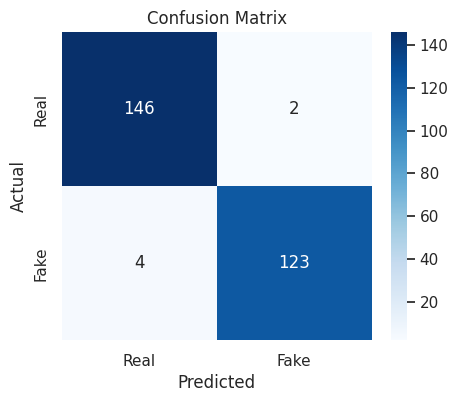

In [ ]:
#Task-6:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Have the model guess on the 20% testing data
y_pred = perceptron_model.forward_propagation(X_test_scaled)

print("--- Test Results ---")
print(f"Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred):.4f}")
print(f"F1-score:  {f1_score(y_test, y_pred):.4f}")

# 3. Pop open a quick confusion matrix
plt.figure(figsize=(5, 4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues',
            xticklabels=['Real', 'Fake'], yticklabels=['Real', 'Fake'])

plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

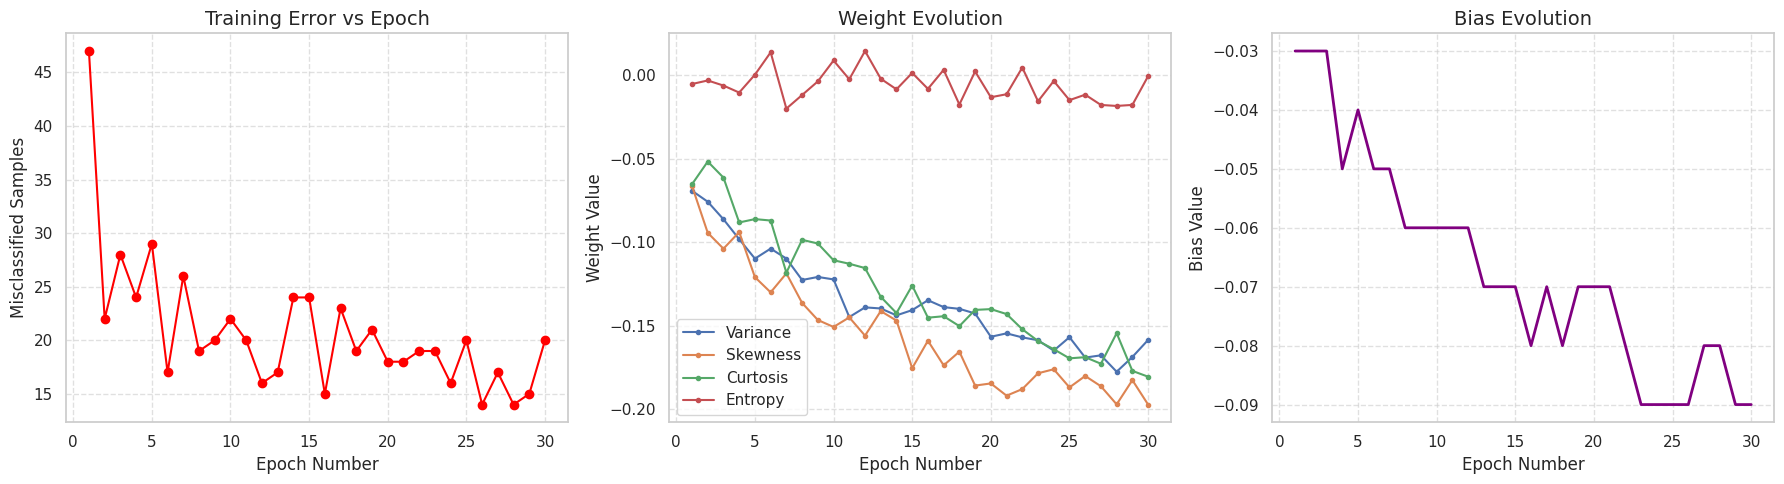

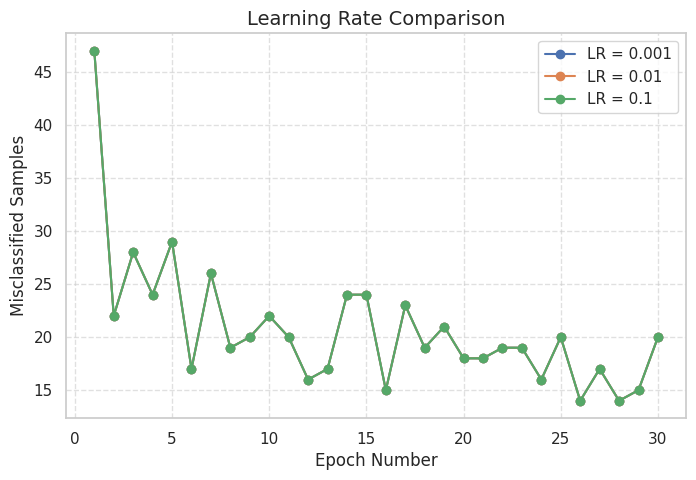

In [ ]:
#Task - 7(Remaining plots)
import matplotlib.pyplot as plt
import contextlib
import io

plt.figure(figsize=(18, 5))
epochs_range = range(1, len(perceptron_model.misclassified_count_per_epoch) + 1)

# Plot A: Training Error vs Epoch
plt.subplot(1, 3, 1)
plt.plot(epochs_range, perceptron_model.misclassified_count_per_epoch, marker='o', color='red')
plt.title('Training Error vs Epoch', fontsize=14)
plt.xlabel('Epoch Number', fontsize=12)
plt.ylabel('Misclassified Samples', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)

# Plot B: Weight Evolution
plt.subplot(1, 3, 2)
plt.plot(epochs_range, perceptron_model.weight_history, marker='.')
plt.title('Weight Evolution', fontsize=14)
plt.xlabel('Epoch Number', fontsize=12)
plt.ylabel('Weight Value', fontsize=12)
plt.legend(['Variance', 'Skewness', 'Curtosis', 'Entropy'])
plt.grid(True, linestyle='--', alpha=0.6)

# Plot C: Bias Evolution
plt.subplot(1, 3, 3)
plt.plot(epochs_range, perceptron_model.bias_history, color='purple', linewidth=2)
plt.title('Bias Evolution', fontsize=14)
plt.xlabel('Epoch Number', fontsize=12)
plt.ylabel('Bias Value', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

# Plot D: Learning Rate Comparison (Silenced)

plt.figure(figsize=(8, 5))

# This 'with' block mutes all print() statements happening inside it!
with contextlib.redirect_stdout(io.StringIO()):
    for lr in [0.001, 0.01, 0.1]:
        temp_model = SingleLayerPerceptron(learning_rate=lr, max_training_epochs=30)
        temp_model.fit(X_train_scaled, y_train)
        temp_epochs = range(1, len(temp_model.misclassified_count_per_epoch) + 1)
        plt.plot(temp_epochs, temp_model.misclassified_count_per_epoch, marker='o', label=f'LR = {lr}')

plt.title('Learning Rate Comparison', fontsize=14)
plt.xlabel('Epoch Number', fontsize=12)
plt.ylabel('Misclassified Samples', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

Additional Task for OR,AND and NOT gates.


Training perceptron for AND gate
Initial weights (bias, w1, w2...): [0. 0. 0.]
  Epoch  1 | Update  1 | input=[0 0] target=0 output=1 -> new weights=[-1.  0.  0.]
  Epoch  1 | Update  2 | input=[1 1] target=1 output=0 -> new weights=[0. 1. 1.]
  Epoch  2 | Update  3 | input=[0 0] target=0 output=1 -> new weights=[-1.  1.  1.]
  Epoch  2 | Update  4 | input=[0 1] target=0 output=1 -> new weights=[-2.  1.  0.]
  Epoch  2 | Update  5 | input=[1 1] target=1 output=0 -> new weights=[-1.  2.  1.]
  Epoch  3 | Update  6 | input=[0 1] target=0 output=1 -> new weights=[-2.  2.  0.]
  Epoch  3 | Update  7 | input=[1 0] target=0 output=1 -> new weights=[-3.  1.  0.]
  Epoch  3 | Update  8 | input=[1 1] target=1 output=0 -> new weights=[-2.  2.  1.]
  Epoch  4 | Update  9 | input=[1 0] target=0 output=1 -> new weights=[-3.  1.  1.]
  Epoch  4 | Update 10 | input=[1 1] target=1 output=0 -> new weights=[-2.  2.  2.]
  Epoch  5 | Update 11 | input=[0 1] target=0 output=1 -> new weights=[-3.  2.  1.]

/tmp/ipykernel_7949/1581807787.py:88: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(xi[0], xi[1], c=color, marker=marker, s=140,


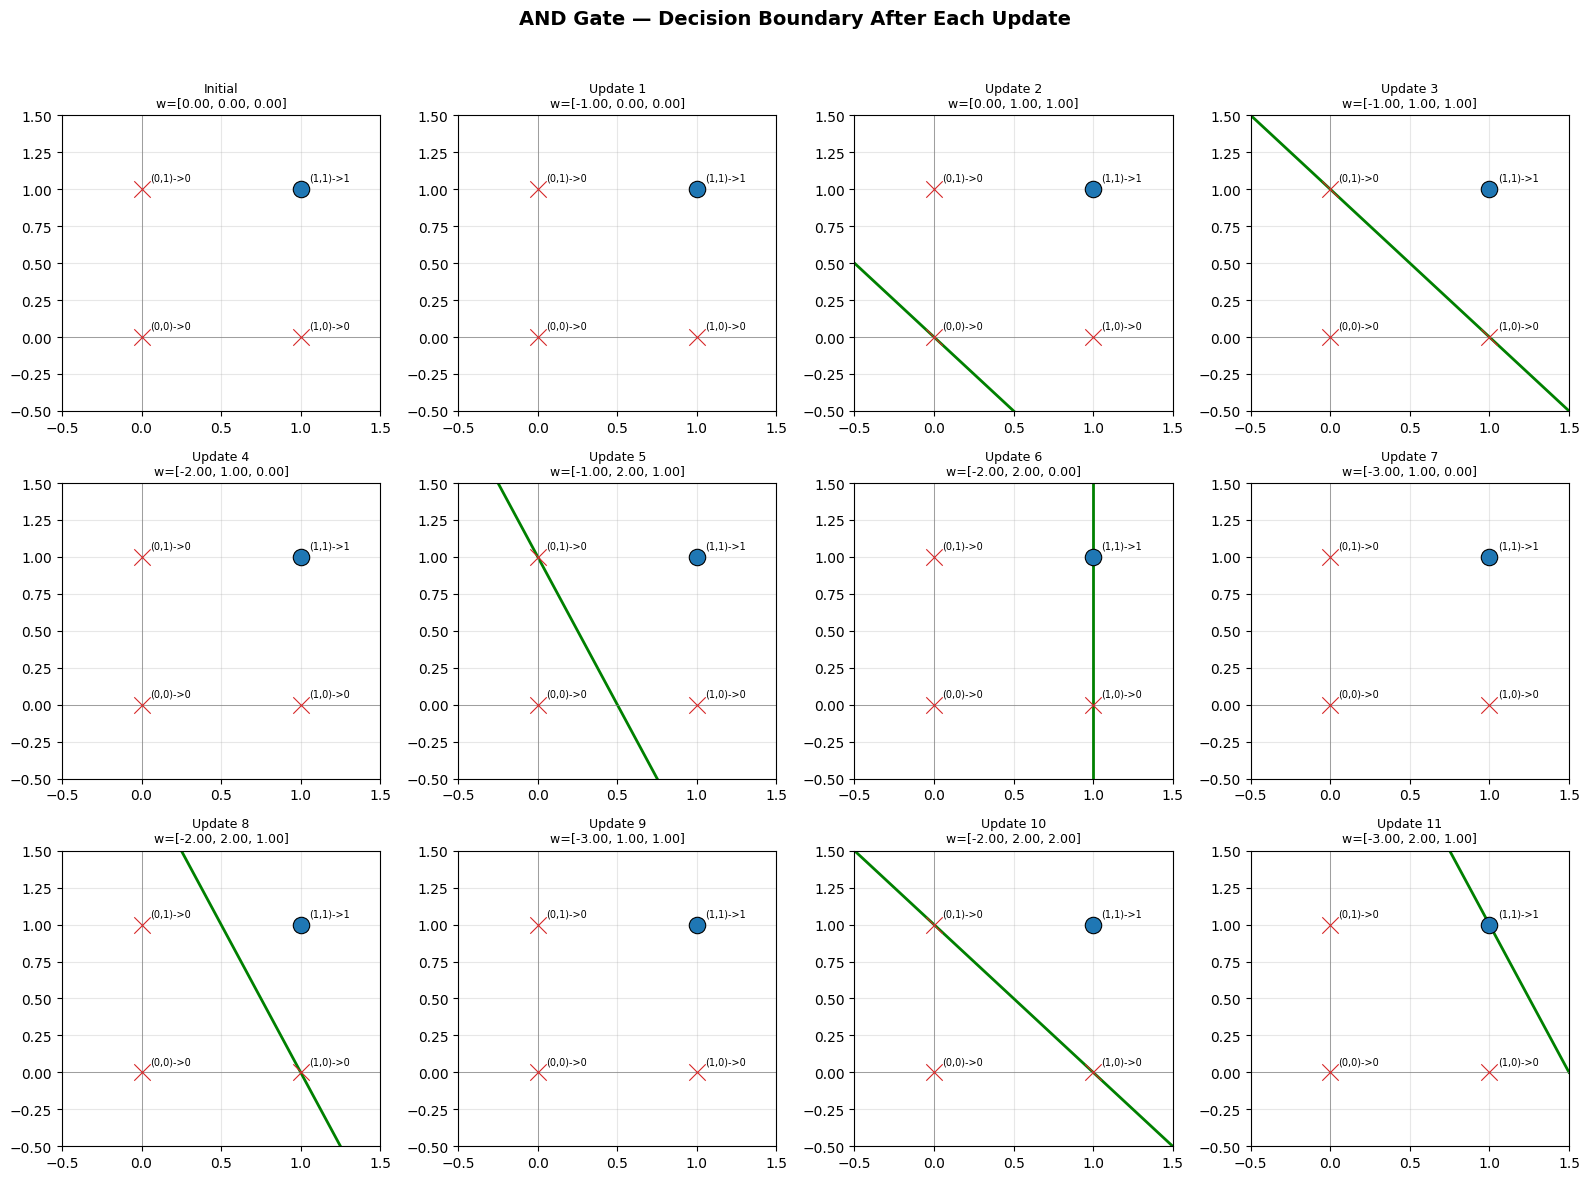


Training perceptron for OR gate
Initial weights (bias, w1, w2...): [0. 0. 0.]
  Epoch  1 | Update  1 | input=[0 0] target=0 output=1 -> new weights=[-1.  0.  0.]
  Epoch  1 | Update  2 | input=[0 1] target=1 output=0 -> new weights=[0. 0. 1.]
  Epoch  2 | Update  3 | input=[0 0] target=0 output=1 -> new weights=[-1.  0.  1.]
  Epoch  2 | Update  4 | input=[1 0] target=1 output=0 -> new weights=[0. 1. 1.]
  Epoch  3 | Update  5 | input=[0 0] target=0 output=1 -> new weights=[-1.  1.  1.]
Converged after epoch 4 (5 total weight updates).
Final weights: [-1.  1.  1.]


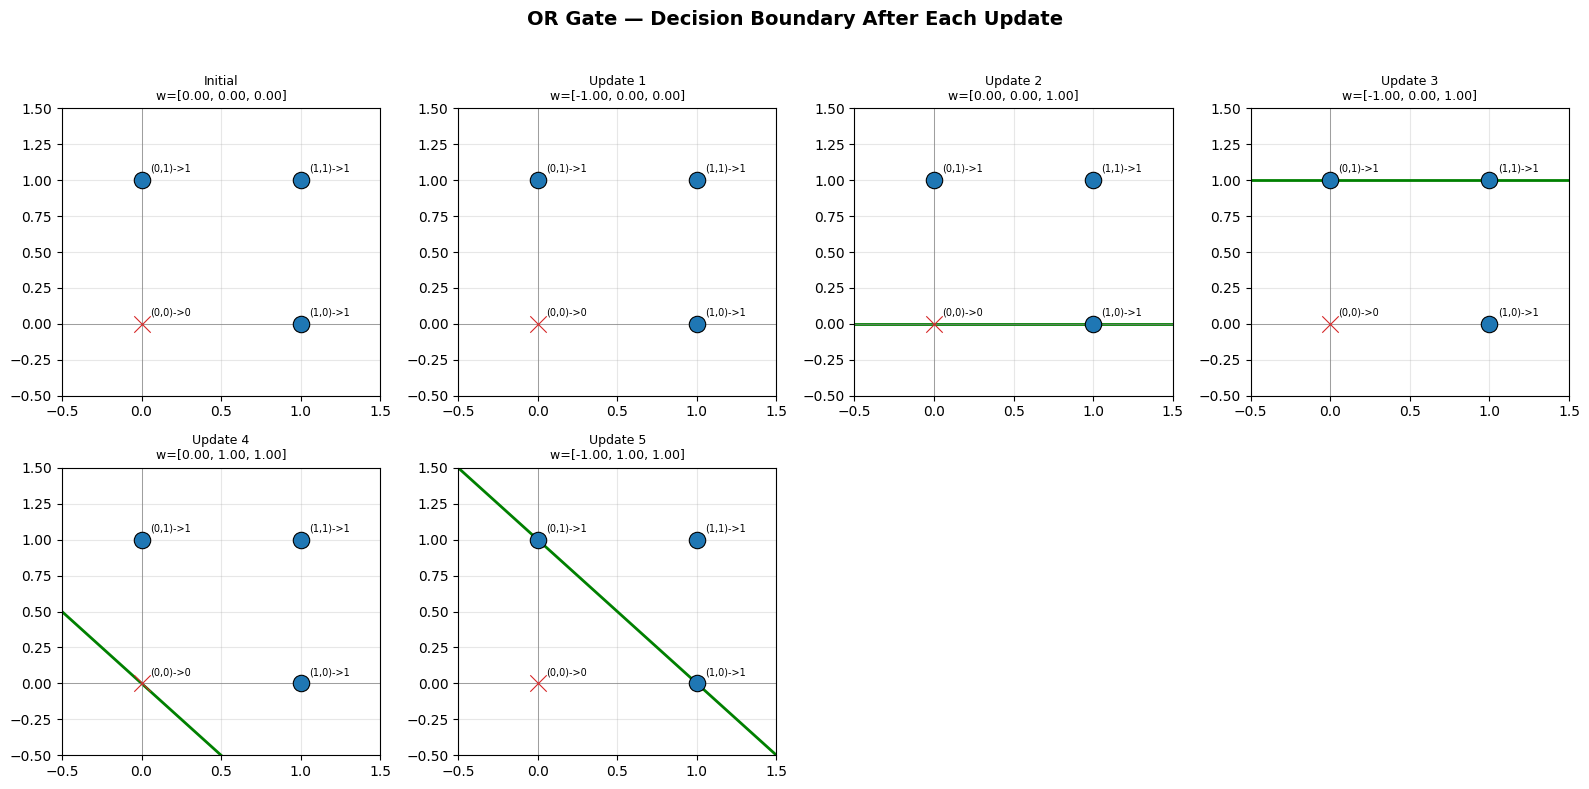


Training perceptron for NOT gate
Initial weights (bias, w1, w2...): [0. 0.]
  Epoch  1 | Update  1 | input=[1] target=0 output=1 -> new weights=[-1. -1.]
  Epoch  2 | Update  2 | input=[0] target=1 output=0 -> new weights=[ 0. -1.]
Converged after epoch 3 (2 total weight updates).
Final weights: [ 0. -1.]


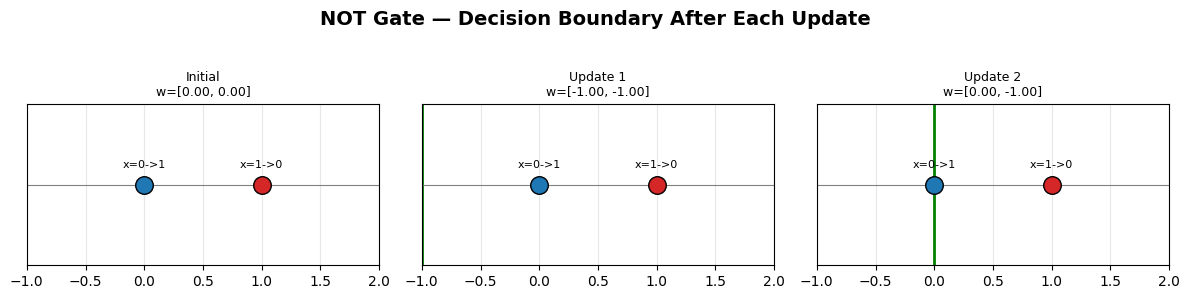


Saved plots:
 - None
 - None
 - None


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import os

OUT_DIR = "/mnt/user-data/outputs"
os.makedirs(OUT_DIR, exist_ok=True)


# ----------------------------------------------------------------------
# 1. Core perceptron algorithm
# ----------------------------------------------------------------------
def step(x):
    return 1 if x >= 0 else 0


def train_perceptron(X, y, lr=1.0, epochs=20, gate_name="GATE"):
    n_samples, n_features = X.shape
    weights = np.zeros(n_features + 1)
    Xb = np.hstack([np.ones((n_samples, 1)), X])
    history = [weights.copy()]
    update_count = 0
    print(f"\n{'='*60}\nTraining perceptron for {gate_name} gate\n{'='*60}")
    print(f"Initial weights (bias, w1, w2...): {weights}")

    for epoch in range(1, epochs + 1):
        errors_this_epoch = 0
        for i in range(n_samples):
            xi = Xb[i]
            target = y[i]
            net_input = np.dot(weights, xi)
            output = step(net_input)
            error = target - output

            if error != 0:
                weights = weights + lr * error * xi
                update_count += 1
                history.append(weights.copy())
                errors_this_epoch += 1
                print(f"  Epoch {epoch:2d} | Update {update_count:2d} | "
                      f"input={X[i]} target={target} output={output} "
                      f"-> new weights={np.round(weights, 3)}")

        if errors_this_epoch == 0:
            print(f"Converged after epoch {epoch} "
                  f"({update_count} total weight updates).")
            print(f"Final weights: {np.round(weights, 3)}")
            break
    else:
        print(f"Did NOT converge within {epochs} epochs "
              f"(final weights: {np.round(weights, 3)})")

    return history

# 2. Plotting helpers
def plot_2input_boundaries(history, X, y, gate_name):
    """Grid of subplots: one per weight update, showing the decision
    boundary line w0 + w1*x1 + w2*x2 = 0 at that point in training."""
    n = len(history)
    cols = min(4, n)
    rows = int(np.ceil(n / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 4 * rows))
    axes = np.array(axes).reshape(-1)

    x_vals = np.linspace(-0.5, 1.5, 100)

    for idx, w in enumerate(history):
        ax = axes[idx]
        for xi, yi in zip(X, y):
            color = "tab:blue" if yi == 1 else "tab:red"
            marker = "o" if yi == 1 else "x"
            ax.scatter(xi[0], xi[1], c=color, marker=marker, s=140,
                       edgecolors="black", linewidths=0.8, zorder=3)
            ax.annotate(f"({xi[0]},{xi[1]})->{yi}", (xi[0], xi[1]),
                        textcoords="offset points", xytext=(6, 6), fontsize=7)

        w0, w1, w2 = w
        if abs(w2) > 1e-9:
            y_vals = -(w0 + w1 * x_vals) / w2
            ax.plot(x_vals, y_vals, "g-", linewidth=2, label="boundary")
        elif abs(w1) > 1e-9:
            ax.axvline(-w0 / w1, color="g", linewidth=2)

        ax.set_xlim(-0.5, 1.5)
        ax.set_ylim(-0.5, 1.5)
        title = "Initial" if idx == 0 else f"Update {idx}"
        ax.set_title(f"{title}\nw=[{w0:.2f}, {w1:.2f}, {w2:.2f}]", fontsize=9)
        ax.axhline(0, color="gray", linewidth=0.5)
        ax.axvline(0, color="gray", linewidth=0.5)
        ax.grid(alpha=0.3)

    for idx in range(n, len(axes)):
        axes[idx].axis("off")

    fig.suptitle(f"{gate_name} Gate — Decision Boundary After Each Update",
                 fontsize=14, fontweight="bold")
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()


def plot_1input_boundaries(history, X, y, gate_name):
    """Same idea but for a single-input gate (NOT): the boundary is a
    single point on the number line, x = -w0/w1."""
    n = len(history)
    cols = min(4, n)
    rows = int(np.ceil(n / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 3 * rows))
    axes = np.array(axes).reshape(-1)

    for idx, w in enumerate(history):
        ax = axes[idx]
        for xi, yi in zip(X, y):
            color = "tab:blue" if yi == 1 else "tab:red"
            ax.scatter(xi[0], 0, c=color, s=160, edgecolors="black", zorder=3)
            ax.annotate(f"x={xi[0]}->{yi}", (xi[0], 0),
                        textcoords="offset points", xytext=(0, 12),
                        ha="center", fontsize=8)

        w0, w1 = w
        if abs(w1) > 1e-9:
            boundary = -w0 / w1
            ax.axvline(boundary, color="g", linewidth=2)

        ax.set_xlim(-1, 2)
        ax.set_ylim(-1, 1)
        ax.set_yticks([])
        title = "Initial" if idx == 0 else f"Update {idx}"
        ax.set_title(f"{title}\nw=[{w0:.2f}, {w1:.2f}]", fontsize=9)
        ax.axhline(0, color="gray", linewidth=0.8)
        ax.grid(alpha=0.3)

    for idx in range(n, len(axes)):
        axes[idx].axis("off")

    fig.suptitle(f"{gate_name} Gate — Decision Boundary After Each Update",
                 fontsize=14, fontweight="bold")
    plt.tight_layout(rect=[0, 0, 1, 0.94])
    plt.show()

# 3. Run for AND, OR, NOT
if __name__ == "__main__":
    LR = 1.0
    EPOCHS = 20

    # --- AND gate ---
    X_and = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
    y_and = np.array([0, 0, 0, 1])
    hist_and = train_perceptron(X_and, y_and, lr=LR, epochs=EPOCHS, gate_name="AND")
    p1 = plot_2input_boundaries(hist_and, X_and, y_and, "AND")

    # --- OR gate ---
    X_or = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
    y_or = np.array([0, 1, 1, 1])
    hist_or = train_perceptron(X_or, y_or, lr=LR, epochs=EPOCHS, gate_name="OR")
    p2 = plot_2input_boundaries(hist_or, X_or, y_or, "OR")

    # --- NOT gate ---
    X_not = np.array([[0], [1]])
    y_not = np.array([1, 0])
    hist_not = train_perceptron(X_not, y_not, lr=LR, epochs=EPOCHS, gate_name="NOT")
    p3 = plot_1input_boundaries(hist_not, X_not, y_not, "NOT")

    print("\nSaved plots:")
    for p in (p1, p2, p3):
        print(" -", p)